In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Style settings
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = "white"

print("Loaded successfully")

Loaded successfully


In [2]:
df = pd.read_csv("winequality-red.csv")

In [3]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [4]:
df = df.drop_duplicates()

In [5]:
df['target'] = [1 if x >=7 else 0 for x in df["quality"]]

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


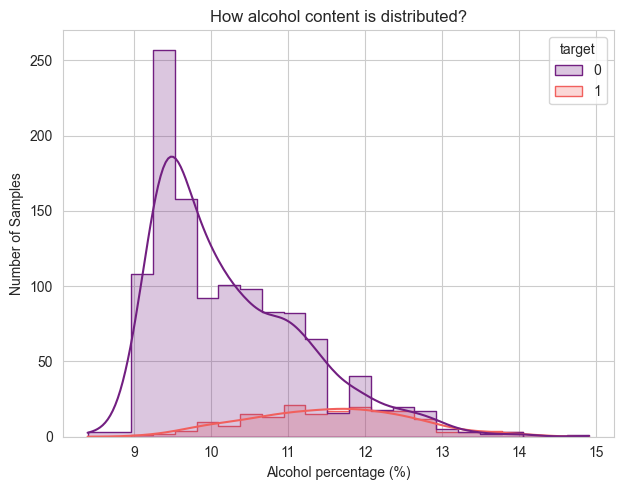

In [7]:
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
sns.histplot(data=df, x= "alcohol", hue="target", kde=True, palette="magma", element="step")
plt.title("How alcohol content is distributed?")
plt.xlabel("Alcohol percentage (%)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [12]:
!pip install --upgrade seaborn

C:\Users\HR\AppData\Local\Temp\ipykernel_10000\2334881248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x= "target",y = "volatile acidity", palette="viridis")


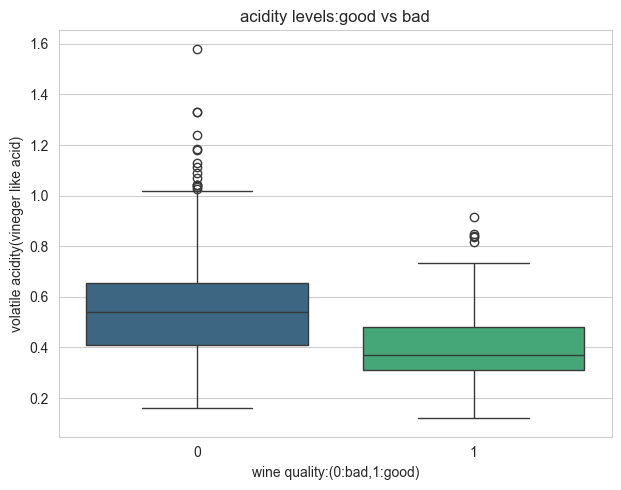

In [13]:
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x= "target",y = "volatile acidity", palette="viridis")
plt.title("acidity levels:good vs bad")
plt.xlabel("wine quality:(0:bad,1:good)")
plt.ylabel("volatile acidity(vineger like acid)")
plt.tight_layout()
plt.show()

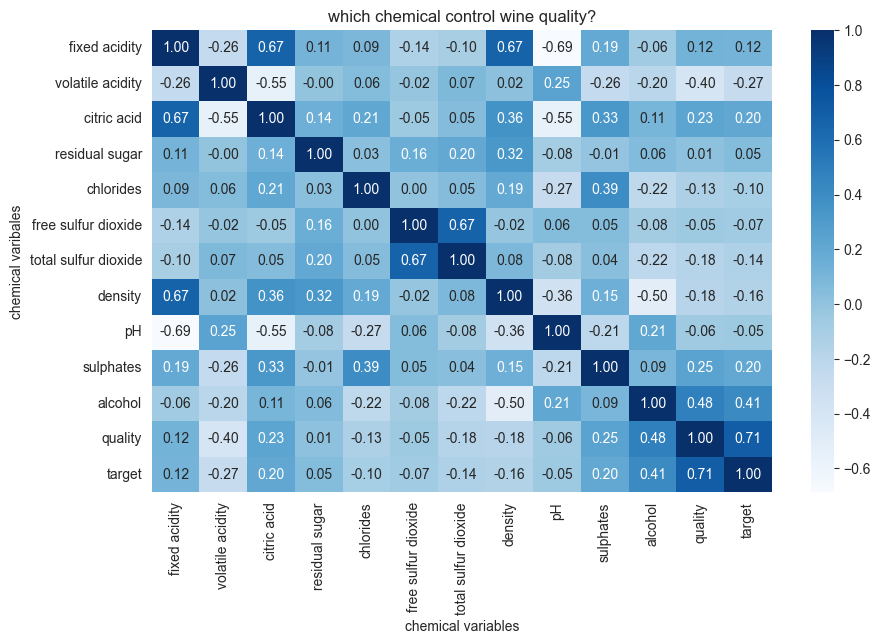

In [14]:
plt.figure(figsize = (10,6))
sns.heatmap(df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("which chemical control wine quality?")
plt.xlabel("chemical variables")
plt.ylabel("chemical varibales")
plt.show()

In [15]:
x = df.drop(["quality", "target"], axis=1)


In [16]:
y  = df['target']

In [17]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,target
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,0
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,0
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
y

0       0
1       0
2       0
3       0
5       0
       ..
1593    0
1594    0
1595    0
1597    0
1598    0
Name: target, Length: 1359, dtype: int64

In [20]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [21]:
x_train_scaled

array([[ 0.35162311, -0.82832312,  0.64877105, ..., -0.25982192,
         0.51985077,  1.98424001],
       [-0.98154785,  0.96589124, -0.98983279, ...,  0.85726724,
        -0.45848943, -0.2158671 ],
       [-0.86561994,  0.18092246, -1.24586464, ...,  0.85726724,
        -0.17074231, -0.39920936],
       ...,
       [-0.86561994, -0.32370033, -0.98983279, ..., -0.06268854,
        -0.05564346, -0.76589387],
       [ 0.35162311, -1.16473831,  0.18791372, ..., -0.91693319,
        -0.6311377 , -0.03252484],
       [ 0.46755102, -1.05259991,  0.75118379, ..., -0.85122206,
        -0.6311377 ,  0.88418646]], shape=(1087, 11))

In [22]:
log_reg = LogisticRegression()
log_reg.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
scores = log_reg.decision_function(x_test_scaled)
x_line = np.linspace(scores.min(), scores.max(), 100)
y_line = 1 / (1 + np.exp(-x_line))

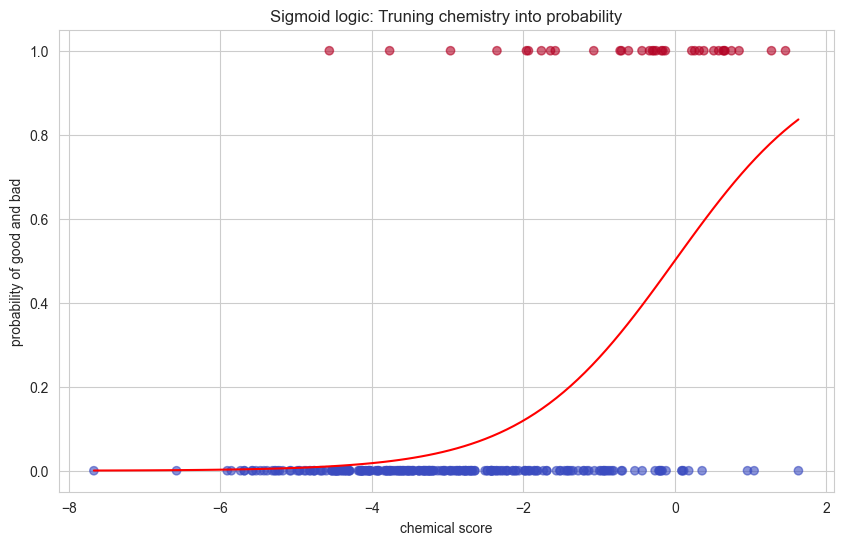

In [24]:
plt.figure(figsize = (10,6))
plt.plot(x_line,y_line,color = "red",label = "sigmoidcurve")
plt.scatter(scores,y_test,c= y_test,cmap = "coolwarm",alpha = 0.6)
plt.title("Sigmoid logic: Truning chemistry into probability")
plt.xlabel("chemical score")
plt.ylabel("probability of good and bad")
plt.show()

In [25]:
SVM_model = SVC(kernel = "rbf",probability  =True)
SVM_model.fit(x_train_scaled,y_train)
SVM_model_pred = SVM_model.predict(x_train_scaled)

In [26]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(x_train, y_train)
dt_pred = dt_model.predict(x_test)

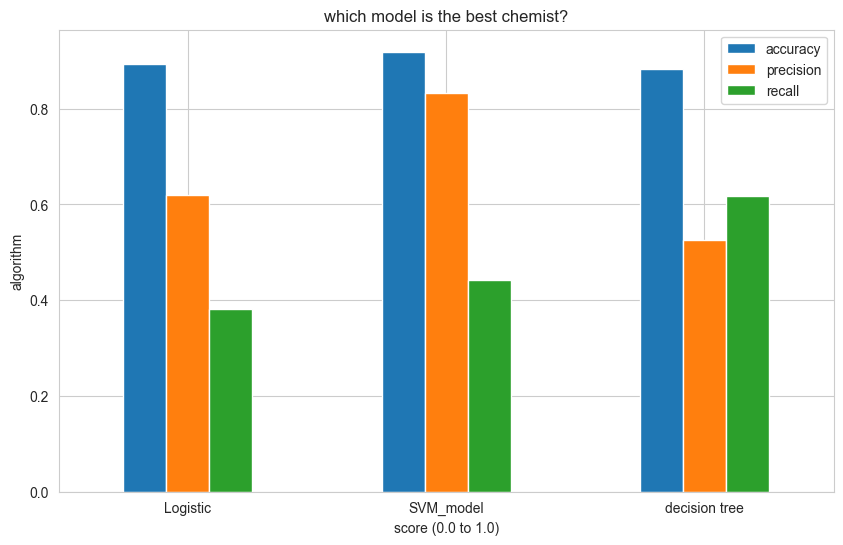

In [27]:
models = {"Logistic": log_reg, "SVM_model": SVM_model, "decision tree": dt_model}

results = []

for name, model in models.items():
    xt = x_test_scaled if name != "decision tree" else x_test
    pred = model.predict(xt)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred)
    })

res_df = pd.DataFrame(results).set_index("model")
res_df.plot(kind="bar", figsize=(10, 6))

plt.title("which model is the best chemist?")
plt.xlabel("score (0.0 to 1.0)")
plt.ylabel("algorithm")
plt.xticks(rotation=0)
plt.show()

In [40]:
import pickle

In [41]:
with open("Wine_Scaler.pkl" ,"wb") as file:
    pickle.dump(scaler, file)

In [42]:
with open("Log_Model.pkl" ,"wb") as file:
    pickle.dump(log_reg, file)

In [43]:
with open("SVM_Model.pkl" ,"wb") as file:
    pickle.dump(SVM_model, file)

In [38]:
with open("DCT.pkl" ,"wb") as file:
    pickle.dump(dt_model, file)